## Need to analyze mouth ratio signal over time 

load the mouth ratio log 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../outputs/logs/mouth_signal_log.csv")
df.head()

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nMissing values:")
print(df.isnull().sum())
print("\nFirst few rows:")
display(df.head())

Shape: (252, 4)

Columns:
Index(['frame_index', 'timestamp_sec', 'mouth_ratio', 'face_detected'], dtype='object')

Missing values:
frame_index        0
timestamp_sec      0
mouth_ratio      114
face_detected      0
dtype: int64

First few rows:


,frame_index,timestamp_sec,mouth_ratio,face_detected
0,1,0.062563,NaN,0
1,2,0.229405,NaN,0
2,3,0.262647,NaN,0
3,4,0.296527,NaN,0
4,5,0.322038,NaN,0


minor cleaning

In [4]:
df_clean = df[df["face_detected"] == 1].copy()
df_clean["mouth_ratio"] = pd.to_numeric(df_clean["mouth_ratio"], errors="coerce")
df_clean = df_clean.dropna(subset=["mouth_ratio"])

print("Original rows:", len(df))
print("Clean rows:", len(df_clean))
df_clean.head()

Original rows: 252
Clean rows: 138


,frame_index,timestamp_sec,mouth_ratio,face_detected
36,37,1.462360,0.430830,1
37,38,1.494788,0.299010,1
38,39,1.527988,0.269062,1
39,40,1.562938,0.275184,1
40,41,1.602147,0.259147,1


visualize mouth ratio overtime 

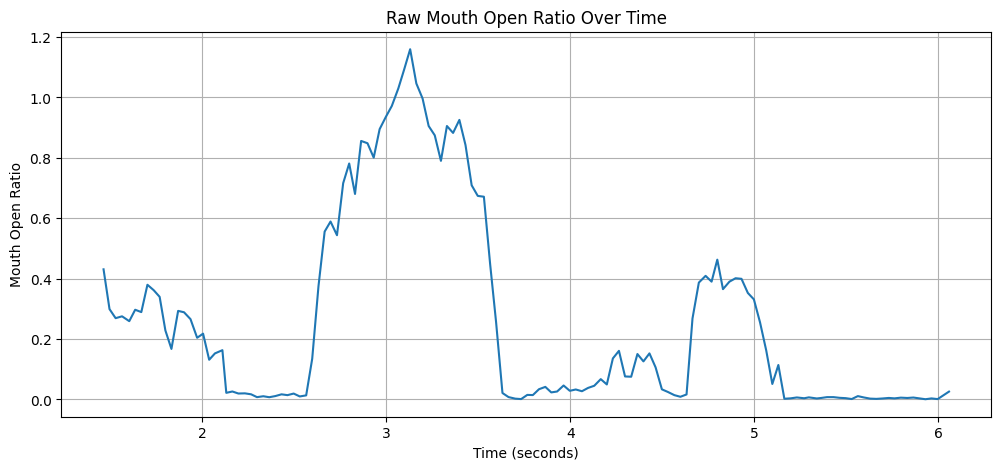

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df_clean["timestamp_sec"], df_clean["mouth_ratio"])
plt.xlabel("Time (seconds)")
plt.ylabel("Mouth Open Ratio")
plt.title("Raw Mouth Open Ratio Over Time")
plt.grid(True)
plt.show()

In [6]:
df_clean["mouth_ratio"].describe()

count    138.000000
mean       0.260149
std        0.321853
min        0.000645
25%        0.011658
50%        0.119942
75%        0.389136
max        1.159667
Name: mouth_ratio, dtype: float64

smooth the plot to control for noise

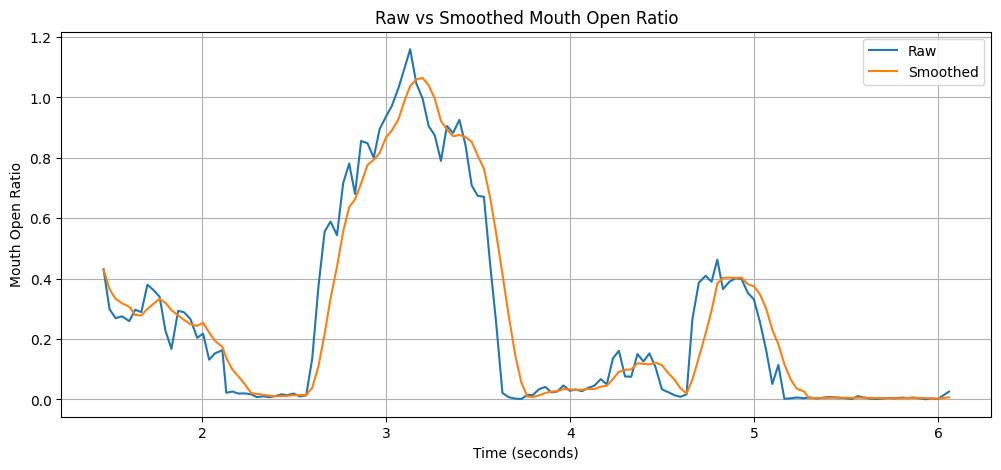

In [8]:
df_clean["mouth_ratio_smooth"] = df_clean["mouth_ratio"].rolling(window=5, min_periods=1).mean()
df_clean.head()
plt.figure(figsize=(12, 5))
plt.plot(df_clean["timestamp_sec"], df_clean["mouth_ratio"], label="Raw")
plt.plot(df_clean["timestamp_sec"], df_clean["mouth_ratio_smooth"], label="Smoothed")
plt.xlabel("Time (seconds)")
plt.ylabel("Mouth Open Ratio")
plt.title("Raw vs Smoothed Mouth Open Ratio")
plt.legend()
plt.grid(True)
plt.show()